In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# データ読み込み
data_path = Path("../../data/raw/assistments_2009_2010/skill_builder_data.csv")
df = pd.read_csv(data_path, encoding='latin1')

print("=== データ形状 ===")
print(f"行数: {len(df)}")
print(f"列数: {len(df.columns)}")
print()

# カラム一覧と型
print("=== カラム一覧 ===")
print(df.dtypes)
print()

# 基本統計量
print("=== 基本情報 ===")
df.info()
print()

# 最初の数行を表示
print("=== データサンプル ===")
display(df.head(10))

/var/folders/zg/773ptkr55z99zw26dvy19_v00000gn/T/ipykernel_68554/1335495223.py:9: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, encoding='latin1')


=== データ形状 ===
行数: 525534
列数: 30

=== カラム一覧 ===
order_id                  int64
assignment_id             int64
user_id                   int64
assistment_id             int64
problem_id                int64
original                  int64
correct                   int64
attempt_count             int64
ms_first_response         int64
tutor_mode               object
answer_type              object
sequence_id               int64
student_class_id          int64
position                  int64
type                     object
base_sequence_id          int64
skill_id                float64
skill_name               object
teacher_id                int64
school_id                 int64
hint_count                int64
hint_total                int64
overlap_time              int64
template_id               int64
answer_id               float64
answer_text              object
first_action              int64
bottom_hint             float64
opportunity               int64
opportunity_original    f

,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0
5,35450555,220674,70363,33172,51457,1,1,1,16031,tutor,...,0,4,16031,30060,NaN,12,0,NaN,4,4.0
6,35450573,220674,70363,33174,51459,1,1,1,15047,tutor,...,0,4,15047,30060,NaN,6,0,NaN,5,5.0
7,35480603,220674,70363,33123,51408,1,1,1,10732,tutor,...,0,3,10732,30059,NaN,55,0,NaN,6,6.0
8,33140811,220674,70677,33168,51453,1,1,1,23241,tutor,...,0,4,23241,30060,NaN,12,0,NaN,1,1.0
9,33140919,220674,70677,33112,51397,1,1,1,11512,tutor,...,0,2,11512,30059,NaN,36,0,NaN,2,2.0


In [2]:
# 欠損値の確認
print("=== 欠損値の数 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    '欠損数': missing,
    '欠損率(%)': missing_pct
}).sort_values('欠損数', ascending=False)
display(missing_df[missing_df['欠損数'] > 0])

=== 欠損値の数 ===


,欠損数,欠損率(%)
answer_id,476856,90.737421
bottom_hint,445627,84.795085
answer_text,94784,18.035750
skill_name,78690,14.973341
opportunity_original,76314,14.521230
skill_id,66326,12.620687


In [3]:
# ユニークなユーザー数とスキル数
print("=== ユニーク数 ===")
print(f"ユニークなuser_id数: {df['user_id'].nunique()}")
print(f"ユニークなskill_id数: {df['skill_id'].nunique()}")
print(f"ユニークなproblem_id数: {df['problem_id'].nunique() if 'problem_id' in df.columns else 'N/A'}")

=== ユニーク数 ===
ユニークなuser_id数: 4217
ユニークなskill_id数: 123
ユニークなproblem_id数: 26688


In [27]:
# ユニークなskill_name一覧と各スキルを解いた人数
order = False  # True: 人数順(降順), False: skill_id順

if 'skill_name' in df.columns:
    # skill_idとskill_nameのユニークな組み合わせを取得
    skill_info = df[['skill_id', 'skill_name']].dropna().drop_duplicates().sort_values('skill_id')
    
    # 各skill_idを解いたユニークなユーザー数を計算
    skill_user_counts = df[df['skill_id'].notna()].groupby('skill_id')['user_id'].nunique().to_dict()
    
    # skill_infoにユーザー数を追加
    skill_info['n_users'] = skill_info['skill_id'].map(skill_user_counts)
    
    # orderに応じてソート
    if order:
        skill_info = skill_info.sort_values('n_users', ascending=False)
        sort_desc = " (人数順)"
    else:
        skill_info = skill_info.sort_values('skill_id')
        sort_desc = " (skill_id順)"
    
    print(f"=== Unique Skill Names (Total: {len(skill_info)}){sort_desc} ===")
    for i, (idx, row) in enumerate(skill_info.iterrows(), 1):
        print(f"ID: {int(row['skill_id'])} {row['skill_name']:60s} - {int(row['n_users']):5d} users")
    
    # DataFrameとしても表示
    print(f"\n=== Skill Information (DataFrame){sort_desc} ===")
    skill_info_display = skill_info.copy()
    skill_info_display['skill_id'] = skill_info_display['skill_id'].astype(int)
    skill_info_display['n_users'] = skill_info_display['n_users'].astype(int)
    display(skill_info_display)
    
else:
    print("Column 'skill_name' not found in the dataset")
    print(f"Available columns: {df.columns.tolist()}")

=== Unique Skill Names (Total: 111) (skill_id順) ===
ID: 1 Box and Whisker                                              -   505 users
ID: 2 Circle Graph                                                 -   616 users
ID: 4 Histogram as Table or Graph                                  -   230 users
ID: 5 Number Line                                                  -   167 users
ID: 8 Scatter Plot                                                 -   354 users
ID: 9 Stem and Leaf Plot                                           -   467 users
ID: 10 Table                                                        -   713 users
ID: 11 Venn Diagram                                                 -   552 users
ID: 12 Mean                                                         -   680 users
ID: 13 Median                                                       -   791 users
ID: 14 Mode                                                         -   572 users
ID: 15 Range                                        

,skill_id,skill_name,n_users
0,1,Box and Whisker,505
3957,2,Circle Graph,616
10165,4,Histogram as Table or Graph,230
11969,5,Number Line,167
13864,8,Scatter Plot,354
...,...,...,...
454630,365,Interpreting Coordinate Graphs,33
455061,368,Solving for a variable,307
456853,371,Simplifying Expressions positive exponents,5
456961,375,Solving Inequalities,166


In [5]:
# skill_idごとのユーザー数分布
print("=== skill_idごとのユーザー数 ===")

# skill_idがNaNでない行のみ抽出
df_skill = df[df['skill_id'].notna()].copy()

# skill_idごとにユニークなユーザー数をカウント
skill_user_counts = df_skill.groupby('skill_id')['user_id'].nunique().reset_index()
skill_user_counts.columns = ['skill_id', 'n_users']

# 問題数もカウント
skill_problem_counts = df_skill.groupby('skill_id').size().reset_index()
skill_problem_counts.columns = ['skill_id', 'n_problems']

# 統合
skill_stats = skill_user_counts.merge(skill_problem_counts, on='skill_id')
skill_stats = skill_stats.sort_values('n_users', ascending=False)

print(f"\nスキル数: {len(skill_stats)}")
print("\n=== ユーザー数の統計量 ===")
print(skill_stats['n_users'].describe())

print("\n=== ユーザー数TOP 100のスキル ===")
with pd.option_context('display.max_rows', None):
    display(skill_stats.head(100))

=== skill_idごとのユーザー数 ===

スキル数: 123

=== ユーザー数の統計量 ===
count     123.000000
mean      341.317073
std       316.460816
min         1.000000
25%        87.500000
50%       264.000000
75%       475.000000
max      1353.000000
Name: n_users, dtype: float64

=== ユーザー数TOP 100のスキル ===

スキル数: 123

=== ユーザー数の統計量 ===
count     123.000000
mean      341.317073
std       316.460816
min         1.000000
25%        87.500000
50%       264.000000
75%       475.000000
max      1353.000000
Name: n_users, dtype: float64

=== ユーザー数TOP 100のスキル ===


,skill_id,n_users,n_problems
82,280.0,1353,11334
79,277.0,1226,22895
30,47.0,1225,20992
44,70.0,1115,22931
55,85.0,1000,7217
37,58.0,988,4737
98,311.0,961,24253
32,49.0,942,7317
14,18.0,939,7438
45,74.0,903,7700


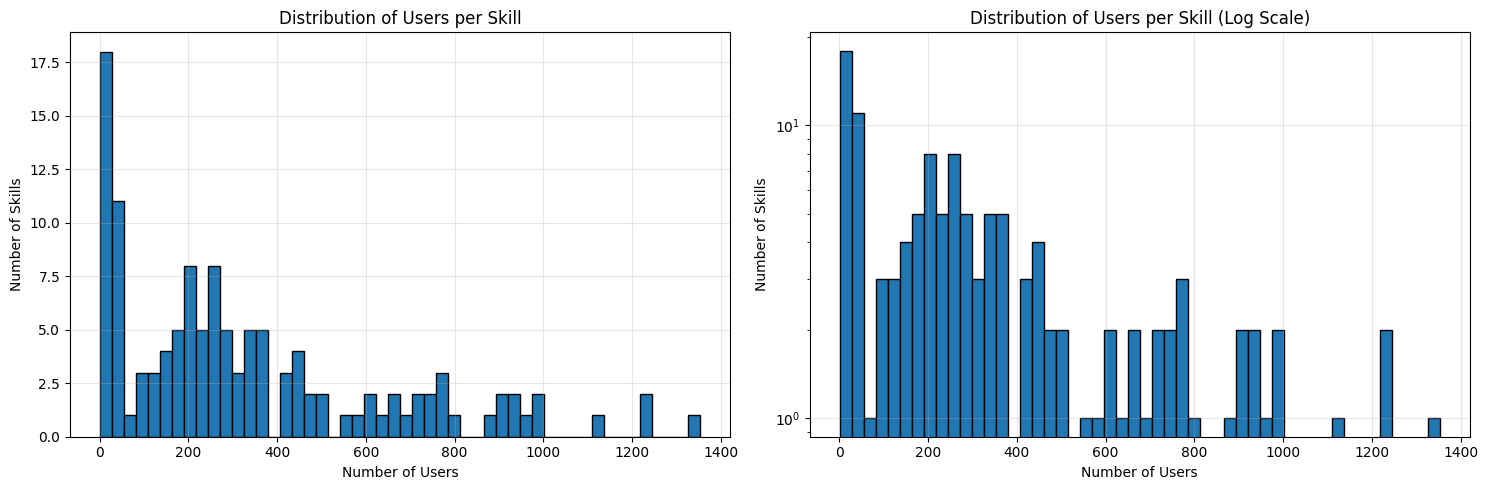

In [6]:
# ユーザー数分布のヒストグラム
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 全体分布
axes[0].hist(skill_stats['n_users'], bins=50, edgecolor='black')
axes[0].set_xlabel('Number of Users')
axes[0].set_ylabel('Number of Skills')
axes[0].set_title('Distribution of Users per Skill')
axes[0].grid(True, alpha=0.3)

# 対数スケール
axes[1].hist(skill_stats['n_users'], bins=50, edgecolor='black')
axes[1].set_xlabel('Number of Users')
axes[1].set_ylabel('Number of Skills')
axes[1].set_title('Distribution of Users per Skill (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# ユーザー数でフィルタリング候補を提示
print("=== フィルタリング候補 ===")
for threshold in [100, 200, 500, 1000]:
    n_skills = len(skill_stats[skill_stats['n_users'] >= threshold])
    print(f"ユーザー数 >= {threshold}: {n_skills}スキル")

=== フィルタリング候補 ===
ユーザー数 >= 100: 90スキル
ユーザー数 >= 200: 75スキル
ユーザー数 >= 500: 29スキル
ユーザー数 >= 1000: 5スキル


In [8]:
# 代表的なスキルの抽出（例: ユーザー数が多いスキル）
# 閾値を調整してください
MIN_USERS = 500  # 最小ユーザー数

selected_skills = skill_stats[skill_stats['n_users'] >= MIN_USERS].copy()
print(f"\n=== 抽出されたスキル（ユーザー数>={MIN_USERS}）===")
print(f"抽出スキル数: {len(selected_skills)}")
display(selected_skills)

# 抽出したスキルIDのリスト
selected_skill_ids = selected_skills['skill_id'].tolist()
print(f"\n抽出されたskill_id: {selected_skill_ids[:10]}...")  # 最初の10個を表示


=== 抽出されたスキル（ユーザー数>=500）===
抽出スキル数: 29


,skill_id,n_users,n_problems
82,280.0,1353,11334
79,277.0,1226,22895
30,47.0,1225,20992
44,70.0,1115,22931
55,85.0,1000,7217
37,58.0,988,4737
98,311.0,961,24253
32,49.0,942,7317
14,18.0,939,7438
45,74.0,903,7700



抽出されたskill_id: [280.0, 277.0, 47.0, 70.0, 85.0, 58.0, 311.0, 49.0, 18.0, 74.0]...


In [9]:
# 選択したスキルに関するデータを抽出
df_selected = df[df['skill_id'].isin(selected_skill_ids)].copy()

print("=== 抽出後のデータ統計 ===")
print(f"総レコード数: {len(df_selected)}")
print(f"ユニークなユーザー数: {df_selected['user_id'].nunique()}")
print(f"ユニークなスキル数: {df_selected['skill_id'].nunique()}")
print(f"ユニークな問題数: {df_selected['problem_id'].nunique() if 'problem_id' in df_selected.columns else 'N/A'}")

=== 抽出後のデータ統計 ===
総レコード数: 255033
ユニークなユーザー数: 3905
ユニークなスキル数: 29
ユニークな問題数: 8775



=== Number of Problems per User ===
count    3905.000000
mean       65.309347
std       176.539878
min         1.000000
25%         9.000000
50%        22.000000
75%        66.000000
max      6157.000000
dtype: float64


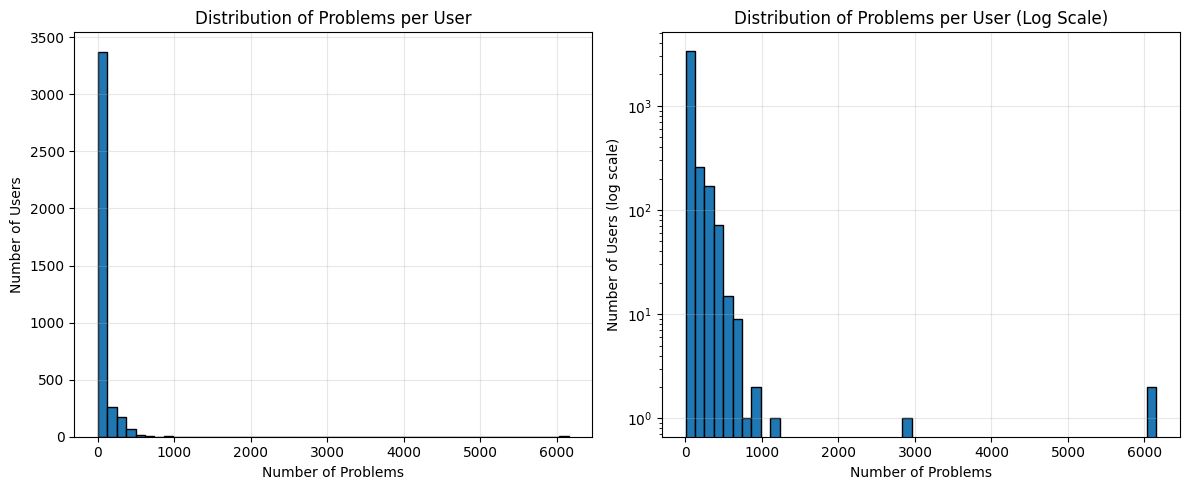

In [10]:
# ユーザーごとの問題数分布
user_problem_counts = df_selected.groupby('user_id').size()

print("\n=== Number of Problems per User ===")
print(user_problem_counts.describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(user_problem_counts, bins=50, edgecolor='black')
plt.xlabel('Number of Problems')
plt.ylabel('Number of Users')
plt.title('Distribution of Problems per User')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(user_problem_counts, bins=50, edgecolor='black')
plt.xlabel('Number of Problems')
plt.ylabel('Number of Users (log scale)')
plt.title('Distribution of Problems per User (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# problem_id、template_id、skill_idのユニーク数をカウント
print("=== problem_id、template_id、skill_idのユニーク数 ===")
print(f"ユニークなproblem_id数: {df['problem_id'].nunique()}")
print(f"ユニークなtemplate_id数: {df['template_id'].nunique()}")
print(f"ユニークなskill_id数: {df['skill_id'].nunique()}")
print()

# 欠損値も確認
print("=== 欠損値の確認 ===")
print(f"problem_idの欠損数: {df['problem_id'].isnull().sum()} ({df['problem_id'].isnull().sum() / len(df) * 100:.2f}%)")
print(f"template_idの欠損数: {df['template_id'].isnull().sum()} ({df['template_id'].isnull().sum() / len(df) * 100:.2f}%)")
print(f"skill_idの欠損数: {df['skill_id'].isnull().sum()} ({df['skill_id'].isnull().sum() / len(df) * 100:.2f}%)")
print()

# それぞれの基本統計
print("=== problem_idの統計 ===")
print(df['problem_id'].describe())
print()

print("=== template_idの統計 ===")
print(df['template_id'].describe())
print()

print("=== skill_idの統計 ===")
print(df['skill_id'].describe())

=== problem_id、template_id、skill_idのユニーク数 ===
ユニークなproblem_id数: 26688
ユニークなtemplate_id数: 816
ユニークなskill_id数: 123

=== 欠損値の確認 ===
problem_idの欠損数: 0 (0.00%)
template_idの欠損数: 0 (0.00%)
skill_idの欠損数: 66326 (12.62%)

=== problem_idの統計 ===
count    525534.000000
mean      84113.537240
std       25818.833052
min          83.000000
25%       61117.000000
50%       86353.000000
75%       91659.000000
max      207348.000000
Name: problem_id, dtype: float64

=== template_idの統計 ===
count    525534.000000
mean      39186.973305
std       12186.156526
min          86.000000
25%       30041.000000
50%       31062.000000
75%       47130.000000
max      106180.000000
Name: template_id, dtype: float64

=== skill_idの統計 ===
count    459208.000000
mean        155.697516
std         127.620640
min           1.000000
25%          47.000000
50%          81.000000
75%         297.000000
max         378.000000
Name: skill_id, dtype: float64


In [12]:
# problem_id、template_id、skill_idの関係性を確認
print("=== IDの関係性確認 ===")

# 欠損値を除外
df_clean = df[['problem_id', 'template_id', 'skill_id']].dropna()

# 1. problem_id が skill_id に対して一意か確認
problem_skill = df_clean.groupby('problem_id')['skill_id'].nunique()
print(f"\n1. problem_id が skill_id に対して一意か:")
print(f"   - 1つのproblem_idに対するskill_idの数:")
print(f"     最小: {problem_skill.min()}, 最大: {problem_skill.max()}")
print(f"   - 複数のskill_idを持つproblem_id数: {(problem_skill > 1).sum()} / {len(problem_skill)}")
if (problem_skill > 1).sum() > 0:
    print(f"   → problem_idはskill_idに対して一意ではない")
    print(f"   複数のskill_idを持つproblem_idの例:")
    multi_skill = problem_skill[problem_skill > 1].head(5)
    for pid, count in multi_skill.items():
        skills = df_clean[df_clean['problem_id'] == pid]['skill_id'].unique()
        print(f"     problem_id={pid}: {count}個のskill_id {skills}")
else:
    print(f"   → problem_idはskill_idに対して一意")

# 2. template_id が skill_id に対して一意か確認
template_skill = df_clean.groupby('template_id')['skill_id'].nunique()
print(f"\n2. template_id が skill_id に対して一意か:")
print(f"   - 1つのtemplate_idに対するskill_idの数:")
print(f"     最小: {template_skill.min()}, 最大: {template_skill.max()}")
print(f"   - 複数のskill_idを持つtemplate_id数: {(template_skill > 1).sum()} / {len(template_skill)}")
if (template_skill > 1).sum() > 0:
    print(f"   → template_idはskill_idに対して一意ではない")
    print(f"   複数のskill_idを持つtemplate_idの例:")
    multi_skill_template = template_skill[template_skill > 1].head(5)
    for tid, count in multi_skill_template.items():
        skills = df_clean[df_clean['template_id'] == tid]['skill_id'].unique()
        print(f"     template_id={tid}: {count}個のskill_id {skills}")
else:
    print(f"   → template_idはskill_idに対して一意")

# 3. problem_id が template_id に対して一意か確認
problem_template = df_clean.groupby('problem_id')['template_id'].nunique()
print(f"\n3. problem_id が template_id に対して一意か:")
print(f"   - 1つのproblem_idに対するtemplate_idの数:")
print(f"     最小: {problem_template.min()}, 最大: {problem_template.max()}")
print(f"   - 複数のtemplate_idを持つproblem_id数: {(problem_template > 1).sum()} / {len(problem_template)}")
if (problem_template > 1).sum() > 0:
    print(f"   → problem_idはtemplate_idに対して一意ではない")
    print(f"   複数のtemplate_idを持つproblem_idの例:")
    multi_template = problem_template[problem_template > 1].head(5)
    for pid, count in multi_template.items():
        templates = df_clean[df_clean['problem_id'] == pid]['template_id'].unique()
        print(f"     problem_id={pid}: {count}個のtemplate_id {templates}")
else:
    print(f"   → problem_idはtemplate_idに対して一意")

# 関係性のサマリー
print(f"\n=== 関係性のサマリー ===")
print(f"total problem_id数: {df['problem_id'].nunique()}")
print(f"total template_id数: {df['template_id'].nunique()}")
print(f"total skill_id数: {df['skill_id'].nunique()}")

=== IDの関係性確認 ===

1. problem_id が skill_id に対して一意か:
   - 1つのproblem_idに対するskill_idの数:
     最小: 1, 最大: 4
   - 複数のskill_idを持つproblem_id数: 3017 / 17751
   → problem_idはskill_idに対して一意ではない
   複数のskill_idを持つproblem_idの例:
     problem_id=86: 3個のskill_id [48. 63. 79.]
     problem_id=252: 4個のskill_id [48. 63. 70. 79.]
     problem_id=4015: 4個のskill_id [47. 63. 70. 77.]
     problem_id=46794: 2個のskill_id [11. 70.]
     problem_id=46797: 2個のskill_id [11. 70.]

2. template_id が skill_id に対して一意か:
   - 1つのtemplate_idに対するskill_idの数:
     最小: 1, 最大: 4
   - 複数のskill_idを持つtemplate_id数: 126 / 658
   → template_idはskill_idに対して一意ではない
   複数のskill_idを持つtemplate_idの例:
     template_id=86: 3個のskill_id [48. 63. 79.]
     template_id=252: 4個のskill_id [48. 63. 70. 79.]
     template_id=4015: 4個のskill_id [47. 63. 70. 77.]
     template_id=29915: 2個のskill_id [74. 85.]
     template_id=29981: 2個のskill_id [309. 310.]

3. problem_id が template_id に対して一意か:
   - 1つのproblem_idに対するtemplate_idの数:
     最小: 1, 最大: 1
   - 複数

In [13]:
# 階層関係の確認: skill_id → template_id → problem_id
print("=== 階層関係の確認 ===")

# 欠損値を除外
df_clean = df[['problem_id', 'template_id', 'skill_id']].dropna()

# 1. 各レベルでの一意性確認
print("\n【各IDの一意性確認】")

# problem_id → template_id (1対1であるべき)
problem_to_template = df_clean.groupby('problem_id')['template_id'].nunique()
print(f"\n1. problem_id → template_id の関係:")
print(f"   - 1つのproblem_idが持つtemplate_idの数: min={problem_to_template.min()}, max={problem_to_template.max()}")
if problem_to_template.max() == 1:
    print(f"   ✓ 各problem_idは1つのtemplate_idに対応している")
else:
    n_violations = (problem_to_template > 1).sum()
    print(f"   ✗ 複数のtemplate_idを持つproblem_idが {n_violations} 個存在")
    print(f"   例:")
    for pid in problem_to_template[problem_to_template > 1].head(3).index:
        templates = df_clean[df_clean['problem_id'] == pid]['template_id'].unique()
        print(f"     problem_id={pid}: template_id={templates}")

# template_id → skill_id (1対1であるべき)
template_to_skill = df_clean.groupby('template_id')['skill_id'].nunique()
print(f"\n2. template_id → skill_id の関係:")
print(f"   - 1つのtemplate_idが持つskill_idの数: min={template_to_skill.min()}, max={template_to_skill.max()}")
if template_to_skill.max() == 1:
    print(f"   ✓ 各template_idは1つのskill_idに対応している")
else:
    n_violations = (template_to_skill > 1).sum()
    print(f"   ✗ 複数のskill_idを持つtemplate_idが {n_violations} 個存在")
    print(f"   例:")
    for tid in template_to_skill[template_to_skill > 1].head(3).index:
        skills = df_clean[df_clean['template_id'] == tid]['skill_id'].unique()
        print(f"     template_id={tid}: skill_id={skills}")

# problem_id → skill_id (推移的に1対1であるべき)
problem_to_skill = df_clean.groupby('problem_id')['skill_id'].nunique()
print(f"\n3. problem_id → skill_id の関係 (推移的):")
print(f"   - 1つのproblem_idが持つskill_idの数: min={problem_to_skill.min()}, max={problem_to_skill.max()}")
if problem_to_skill.max() == 1:
    print(f"   ✓ 各problem_idは1つのskill_idに対応している")
else:
    n_violations = (problem_to_skill > 1).sum()
    print(f"   ✗ 複数のskill_idを持つproblem_idが {n_violations} 個存在")
    print(f"   例:")
    for pid in problem_to_skill[problem_to_skill > 1].head(3).index:
        skills = df_clean[df_clean['problem_id'] == pid]['skill_id'].unique()
        print(f"     problem_id={pid}: skill_id={skills}")

# 2. 階層構造の整合性確認
print(f"\n【階層構造の整合性確認】")
hierarchy_valid = (problem_to_template.max() == 1) and (template_to_skill.max() == 1) and (problem_to_skill.max() == 1)

if hierarchy_valid:
    print("✓ 階層構造は正しく成立しています:")
    print("  skill_id")
    print("   └─ template_id")
    print("       └─ problem_id")
else:
    print("✗ 階層構造に問題があります")

# 3. 各レベルの統計
print(f"\n【階層統計】")
skill_to_template = df_clean.groupby('skill_id')['template_id'].nunique()
skill_to_problem = df_clean.groupby('skill_id')['problem_id'].nunique()
template_to_problem = df_clean.groupby('template_id')['problem_id'].nunique()

print(f"skill_id数: {df_clean['skill_id'].nunique()}")
print(f"  └─ 1つのskill_idあたりのtemplate_id数: 平均={skill_to_template.mean():.2f}, 最小={skill_to_template.min()}, 最大={skill_to_template.max()}")
print(f"  └─ 1つのskill_idあたりのproblem_id数: 平均={skill_to_problem.mean():.2f}, 最小={skill_to_problem.min()}, 最大={skill_to_problem.max()}")
print(f"\ntemplate_id数: {df_clean['template_id'].nunique()}")
print(f"  └─ 1つのtemplate_idあたりのproblem_id数: 平均={template_to_problem.mean():.2f}, 最小={template_to_problem.min()}, 最大={template_to_problem.max()}")
print(f"\nproblem_id数: {df_clean['problem_id'].nunique()}")

=== 階層関係の確認 ===

【各IDの一意性確認】

1. problem_id → template_id の関係:
   - 1つのproblem_idが持つtemplate_idの数: min=1, max=1
   ✓ 各problem_idは1つのtemplate_idに対応している

2. template_id → skill_id の関係:
   - 1つのtemplate_idが持つskill_idの数: min=1, max=4
   ✗ 複数のskill_idを持つtemplate_idが 126 個存在
   例:
     template_id=86: skill_id=[48. 63. 79.]
     template_id=252: skill_id=[48. 63. 70. 79.]
     template_id=4015: skill_id=[47. 63. 70. 77.]

【各IDの一意性確認】

1. problem_id → template_id の関係:
   - 1つのproblem_idが持つtemplate_idの数: min=1, max=1
   ✓ 各problem_idは1つのtemplate_idに対応している

2. template_id → skill_id の関係:
   - 1つのtemplate_idが持つskill_idの数: min=1, max=4
   ✗ 複数のskill_idを持つtemplate_idが 126 個存在
   例:
     template_id=86: skill_id=[48. 63. 79.]
     template_id=252: skill_id=[48. 63. 70. 79.]
     template_id=4015: skill_id=[47. 63. 70. 77.]

3. problem_id → skill_id の関係 (推移的):
   - 1つのproblem_idが持つskill_idの数: min=1, max=4
   ✗ 複数のskill_idを持つproblem_idが 3017 個存在
   例:
     problem_id=86: skill_id=[48. 63. 79.]
     p

In [14]:
# problem_idとtemplate_idのskill_id一致性確認
print("=== problem_idとtemplate_idのskill_id一致性確認 ===")

# 欠損値を除外
df_clean = df[['problem_id', 'template_id', 'skill_id']].dropna()

# 各problem_idとそのtemplate_idが持つskill_idを取得
problem_skills = df_clean.groupby('problem_id')['skill_id'].apply(set).to_dict()
problem_templates = df_clean.groupby('problem_id')['template_id'].first().to_dict()
template_skills = df_clean.groupby('template_id')['skill_id'].apply(set).to_dict()

# 一致性をチェック
mismatches = []
for problem_id, p_skills in problem_skills.items():
    template_id = problem_templates[problem_id]
    t_skills = template_skills[template_id]
    
    if p_skills != t_skills:
        mismatches.append({
            'problem_id': problem_id,
            'template_id': template_id,
            'problem_skills': sorted(p_skills),
            'template_skills': sorted(t_skills),
            'problem_only': sorted(p_skills - t_skills),
            'template_only': sorted(t_skills - p_skills)
        })

print(f"\n総problem_id数: {len(problem_skills)}")
print(f"skill_idが不一致のproblem_id数: {len(mismatches)}")

if len(mismatches) == 0:
    print("\n✓ 全てのproblem_idについて、そのskill_idと所属するtemplate_idのskill_idが一致しています")
else:
    print(f"\n✗ {len(mismatches)} 個のproblem_idでskill_idが不一致です")
    print(f"   不一致率: {len(mismatches) / len(problem_skills) * 100:.2f}%")
    
    print("\n不一致の例（最初の10件）:")
    for i, mismatch in enumerate(mismatches[:10], 1):
        print(f"\n{i}. problem_id={mismatch['problem_id']}, template_id={mismatch['template_id']}")
        print(f"   problem_idのskill_id: {mismatch['problem_skills']}")
        print(f"   template_idのskill_id: {mismatch['template_skills']}")
        if mismatch['problem_only']:
            print(f"   problem_idのみにあるskill_id: {mismatch['problem_only']}")
        if mismatch['template_only']:
            print(f"   template_idのみにあるskill_id: {mismatch['template_only']}")

# 不一致のパターン分析
if len(mismatches) > 0:
    print("\n=== 不一致パターンの分析 ===")
    
    # problem_idがtemplate_idのサブセットか
    problem_subset = sum(1 for m in mismatches if set(m['problem_skills']).issubset(set(m['template_skills'])))
    template_subset = sum(1 for m in mismatches if set(m['template_skills']).issubset(set(m['problem_skills'])))
    neither = len(mismatches) - problem_subset - template_subset
    
    print(f"problem_idのskill_idがtemplate_idのサブセット: {problem_subset} 件")
    print(f"template_idのskill_idがproblem_idのサブセット: {template_subset} 件")
    print(f"どちらもサブセットでない: {neither} 件")

=== problem_idとtemplate_idのskill_id一致性確認 ===

総problem_id数: 17751
skill_idが不一致のproblem_id数: 1017

✗ 1017 個のproblem_idでskill_idが不一致です
   不一致率: 5.73%

不一致の例（最初の10件）:

1. problem_id=83, template_id=86
   problem_idのskill_id: [63.0]
   template_idのskill_id: [48.0, 63.0, 79.0]
   template_idのみにあるskill_id: [48.0, 79.0]

2. problem_id=84, template_id=86
   problem_idのskill_id: [79.0]
   template_idのskill_id: [48.0, 63.0, 79.0]
   template_idのみにあるskill_id: [48.0, 63.0]

3. problem_id=85, template_id=86
   problem_idのskill_id: [48.0]
   template_idのskill_id: [48.0, 63.0, 79.0]
   template_idのみにあるskill_id: [63.0, 79.0]

4. problem_id=249, template_id=252
   problem_idのskill_id: [63.0]
   template_idのskill_id: [48.0, 63.0, 70.0, 79.0]
   template_idのみにあるskill_id: [48.0, 70.0, 79.0]

5. problem_id=250, template_id=252
   problem_idのskill_id: [79.0]
   template_idのskill_id: [48.0, 63.0, 70.0, 79.0]
   template_idのみにあるskill_id: [48.0, 63.0, 70.0]

6. problem_id=251, template_id=252
   problem_idのski

In [15]:
# 特定のproblem_idとtemplate_idの詳細を確認
print("=== 不一致の原因調査 ===")

# 例: problem_id=48058, template_id=30551
example_problem_id = 48058
example_template_id = 30551

print(f"\n【problem_id={example_problem_id}の全レコード】")
example_df = df[df['problem_id'] == example_problem_id][['problem_id', 'template_id', 'skill_id']].dropna()
display(example_df)

print(f"\n【template_id={example_template_id}の全レコード（先頭20件）】")
template_df = df[df['template_id'] == example_template_id][['problem_id', 'template_id', 'skill_id']].dropna()
print(f"総レコード数: {len(template_df)}")
display(template_df.head(20))

print(f"\n【template_id={example_template_id}のユニークなproblem_idとskill_idの組み合わせ】")
template_combinations = template_df.groupby(['problem_id', 'skill_id']).size().reset_index(name='count')
display(template_combinations)

print(f"\n【分析】")
print(f"template_id={example_template_id}は{template_df['problem_id'].nunique()}個のproblem_idを持つ")
print(f"そのうちのproblem_id={example_problem_id}は skill_id={sorted(example_df['skill_id'].unique())} を持つ")
print(f"しかし、同じtemplate_idの他のproblem_idが skill_id=76.0 も持っている")

print("\n【結論】")
print("1つのtemplate_idが複数のproblem_idを含む")
print("→ 各problem_idは異なるskill_idの組み合わせを持つことがある")
print("→ template_idのskill_idは、そのtemplate_id配下の全problem_idのskill_idの和集合")
print("\nつまり:")
print("  template_id (問題のテンプレート)")
print("    ├─ problem_id A: skill_id [10, 64]")
print("    ├─ problem_id B: skill_id [76]")
print("    └─ problem_id C: skill_id [10, 64, 76]")
print("  → template_idのskill_id = [10, 64, 76]")

=== 不一致の原因調査 ===

【problem_id=48058の全レコード】


,problem_id,template_id,skill_id
20405,48058,30551,10.0
20809,48058,30551,10.0
20892,48058,30551,10.0
20923,48058,30551,10.0
20957,48058,30551,10.0
20977,48058,30551,10.0
21001,48058,30551,10.0
21019,48058,30551,10.0
21186,48058,30551,10.0
21833,48058,30551,10.0



【template_id=30551の全レコード（先頭20件）】
総レコード数: 1234


,problem_id,template_id,skill_id
19559,48130,30551,10.0
19597,48086,30551,10.0
19611,48162,30551,10.0
19702,48150,30551,10.0
19725,48070,30551,10.0
19775,48098,30551,10.0
19776,48130,30551,10.0
19792,48146,30551,10.0
19793,48070,30551,10.0
19826,48082,30551,10.0



【template_id=30551のユニークなproblem_idとskill_idの組み合わせ】


,problem_id,skill_id,count
0,48054,10.0,16
1,48054,64.0,16
2,48058,10.0,21
3,48058,64.0,21
4,48062,10.0,24
5,48062,64.0,24
6,48066,10.0,15
7,48066,64.0,15
8,48070,10.0,23
9,48070,64.0,23



【分析】
template_id=30551は30個のproblem_idを持つ
そのうちのproblem_id=48058は skill_id=[np.float64(10.0), np.float64(64.0)] を持つ
しかし、同じtemplate_idの他のproblem_idが skill_id=76.0 も持っている

【結論】
1つのtemplate_idが複数のproblem_idを含む
→ 各problem_idは異なるskill_idの組み合わせを持つことがある
→ template_idのskill_idは、そのtemplate_id配下の全problem_idのskill_idの和集合

つまり:
  template_id (問題のテンプレート)
    ├─ problem_id A: skill_id [10, 64]
    ├─ problem_id B: skill_id [76]
    └─ problem_id C: skill_id [10, 64, 76]
  → template_idのskill_id = [10, 64, 76]


=== template_idごとのskill_id数の集計 ===

【基本統計】
count    658.000000
mean       1.240122
std        0.551821
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.000000
Name: n_skills, dtype: float64

【skill_id数の分布】
n_skills
1    532
2    102
3     16
4      8
Name: count, dtype: int64

【skill_id数が多いtemplate_idのTOP 20】


,template_id,n_skills
218,30861,4
411,52571,4
1,252,4
646,89341,4
8,4015,4
471,56516,4
201,30790,4
230,30987,4
184,30525,3
183,30524,3


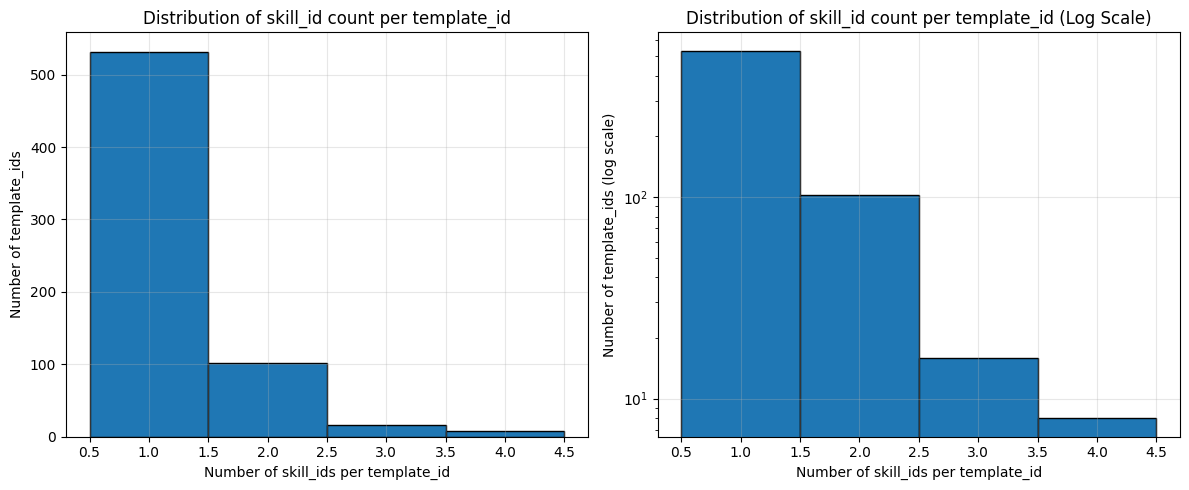


【サマリー】
総template_id数: 658
skill_idが1つだけのtemplate_id: 532 (80.85%)
複数のskill_idを持つtemplate_id: 126 (19.15%)


In [16]:
# template_idごとのskill_id数を集計
print("=== template_idごとのskill_id数の集計 ===")

df_clean = df[['template_id', 'skill_id']].dropna()

# 各template_idが持つskill_idの数をカウント
template_skill_count = df_clean.groupby('template_id')['skill_id'].nunique().reset_index()
template_skill_count.columns = ['template_id', 'n_skills']
template_skill_count = template_skill_count.sort_values('n_skills', ascending=False)

print("\n【基本統計】")
print(template_skill_count['n_skills'].describe())

print("\n【skill_id数の分布】")
skill_count_dist = template_skill_count['n_skills'].value_counts().sort_index()
print(skill_count_dist)

print("\n【skill_id数が多いtemplate_idのTOP 20】")
display(template_skill_count.head(20))

# ヒストグラム
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(template_skill_count['n_skills'], bins=range(1, template_skill_count['n_skills'].max()+2), 
         edgecolor='black', align='left')
plt.xlabel('Number of skill_ids per template_id')
plt.ylabel('Number of template_ids')
plt.title('Distribution of skill_id count per template_id')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(template_skill_count['n_skills'], bins=range(1, template_skill_count['n_skills'].max()+2), 
         edgecolor='black', align='left')
plt.xlabel('Number of skill_ids per template_id')
plt.ylabel('Number of template_ids (log scale)')
plt.title('Distribution of skill_id count per template_id (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n【サマリー】")
print(f"総template_id数: {len(template_skill_count)}")
print(f"skill_idが1つだけのtemplate_id: {(template_skill_count['n_skills'] == 1).sum()} ({(template_skill_count['n_skills'] == 1).sum() / len(template_skill_count) * 100:.2f}%)")
print(f"複数のskill_idを持つtemplate_id: {(template_skill_count['n_skills'] > 1).sum()} ({(template_skill_count['n_skills'] > 1).sum() / len(template_skill_count) * 100:.2f}%)")

=== problem_idごとのskill_id数の集計 ===

【基本統計】
count    17751.000000
mean         1.196890
std          0.470233
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: n_skills, dtype: float64

【skill_id数の分布】
n_skills
1    14734
2     2620
3      316
4       81
Name: count, dtype: int64

【skill_id数が多いproblem_idのTOP 20】


,problem_id,n_skills
12753,93469,4
12734,93450,4
12751,93467,4
12750,93466,4
12749,93465,4
12748,93464,4
12747,93463,4
12746,93462,4
12745,93461,4
12744,93460,4


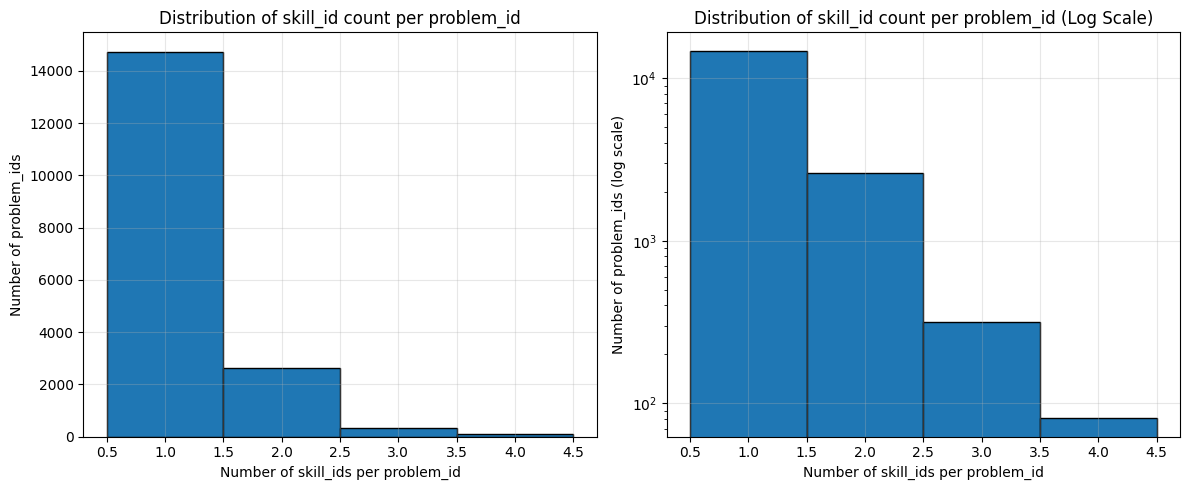


【サマリー】
総problem_id数: 17751
skill_idが1つだけのproblem_id: 14734 (83.00%)
複数のskill_idを持つproblem_id: 3017 (17.00%)


In [17]:
# problem_idごとのskill_id数を集計
print("=== problem_idごとのskill_id数の集計 ===")

df_clean = df[['problem_id', 'skill_id']].dropna()

# 各problem_idが持つskill_idの数をカウント
problem_skill_count = df_clean.groupby('problem_id')['skill_id'].nunique().reset_index()
problem_skill_count.columns = ['problem_id', 'n_skills']
problem_skill_count = problem_skill_count.sort_values('n_skills', ascending=False)

print("\n【基本統計】")
print(problem_skill_count['n_skills'].describe())

print("\n【skill_id数の分布】")
skill_count_dist = problem_skill_count['n_skills'].value_counts().sort_index()
print(skill_count_dist)

print("\n【skill_id数が多いproblem_idのTOP 20】")
display(problem_skill_count.head(20))

# ヒストグラム
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(problem_skill_count['n_skills'], bins=range(1, problem_skill_count['n_skills'].max()+2), 
         edgecolor='black', align='left')
plt.xlabel('Number of skill_ids per problem_id')
plt.ylabel('Number of problem_ids')
plt.title('Distribution of skill_id count per problem_id')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(problem_skill_count['n_skills'], bins=range(1, problem_skill_count['n_skills'].max()+2), 
         edgecolor='black', align='left')
plt.xlabel('Number of skill_ids per problem_id')
plt.ylabel('Number of problem_ids (log scale)')
plt.title('Distribution of skill_id count per problem_id (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n【サマリー】")
print(f"総problem_id数: {len(problem_skill_count)}")
print(f"skill_idが1つだけのproblem_id: {(problem_skill_count['n_skills'] == 1).sum()} ({(problem_skill_count['n_skills'] == 1).sum() / len(problem_skill_count) * 100:.2f}%)")
print(f"複数のskill_idを持つproblem_id: {(problem_skill_count['n_skills'] > 1).sum()} ({(problem_skill_count['n_skills'] > 1).sum() / len(problem_skill_count) * 100:.2f}%)")

=== template_idごとの正解率集計 ===

【基本統計】
count    816.000000
mean       0.610769
std        0.245279
min        0.000000
25%        0.475995
50%        0.654783
75%        0.782191
max        1.000000
Name: accuracy, dtype: float64

【正解率が高いtemplate_idのTOP 20】


,template_id,accuracy,n_correct,n_total
599,62271,1.0,3,3
526,58211,1.0,3,3
529,58215,1.0,2,2
755,78174,1.0,59,59
530,58216,1.0,2,2
722,74520,1.0,3,3
571,60259,1.0,1,1
575,60463,1.0,1,1
584,61568,1.0,1,1
585,61570,1.0,1,1



【正解率が低いtemplate_idのTOP 20】


,template_id,accuracy,n_correct,n_total
500,57330,0.0,0,1
506,57618,0.0,0,2
507,57636,0.0,0,1
717,74357,0.0,0,6
718,74360,0.0,0,6
548,58586,0.0,0,2
538,58284,0.0,0,7
582,60751,0.0,0,1
444,54421,0.0,0,8
588,61573,0.0,0,1


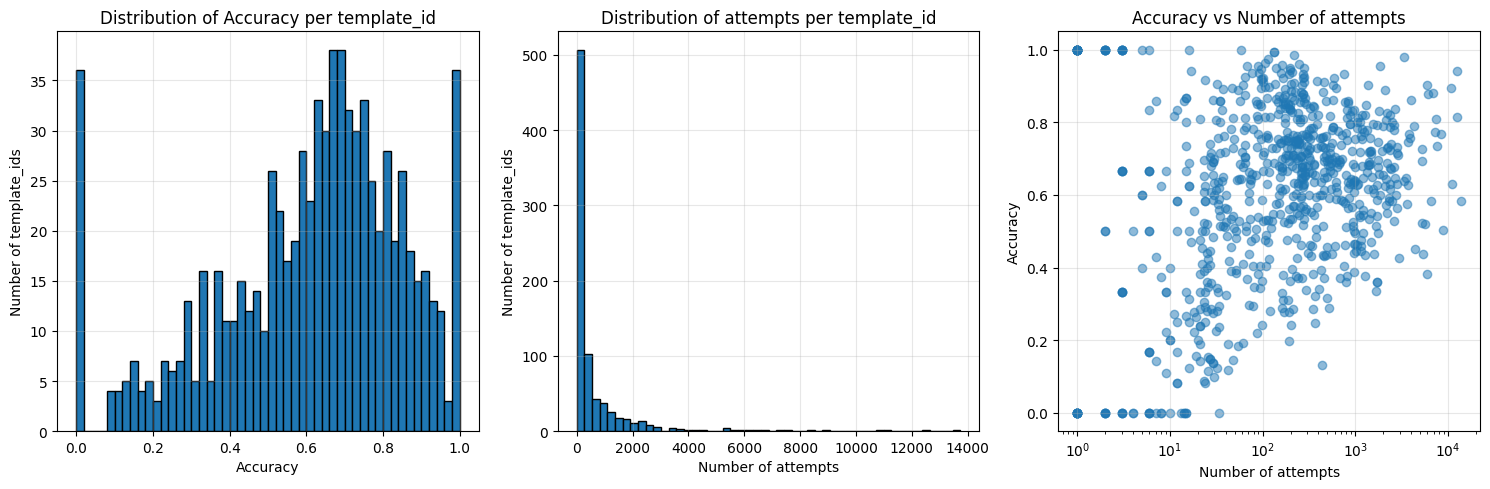


【サマリー】
総template_id数: 816
平均正解率: 0.6108
中央値正解率: 0.6548
正解率 >= 0.8 のtemplate_id: 186 (22.79%)
正解率 < 0.5 のtemplate_id: 216 (26.47%)


In [18]:
# template_idごとの正解率を集計
print("=== template_idごとの正解率集計 ===")

# correctカラムが存在するか確認
if 'correct' in df.columns:
    df_clean = df[['template_id', 'correct']].dropna()
    
    # 各template_idの正解率を計算
    template_accuracy = df_clean.groupby('template_id').agg({
        'correct': ['mean', 'sum', 'count']
    }).reset_index()
    
    template_accuracy.columns = ['template_id', 'accuracy', 'n_correct', 'n_total']
    template_accuracy = template_accuracy.sort_values('accuracy', ascending=False)
    
    print("\n【基本統計】")
    print(template_accuracy['accuracy'].describe())
    
    print("\n【正解率が高いtemplate_idのTOP 20】")
    display(template_accuracy.head(20))
    
    print("\n【正解率が低いtemplate_idのTOP 20】")
    display(template_accuracy.tail(20))
    
    # ヒストグラム
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.hist(template_accuracy['accuracy'], bins=50, edgecolor='black')
    plt.xlabel('Accuracy')
    plt.ylabel('Number of template_ids')
    plt.title('Distribution of Accuracy per template_id')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.hist(template_accuracy['n_total'], bins=50, edgecolor='black')
    plt.xlabel('Number of attempts')
    plt.ylabel('Number of template_ids')
    plt.title('Distribution of attempts per template_id')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.scatter(template_accuracy['n_total'], template_accuracy['accuracy'], alpha=0.5)
    plt.xlabel('Number of attempts')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Number of attempts')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n【サマリー】")
    print(f"総template_id数: {len(template_accuracy)}")
    print(f"平均正解率: {template_accuracy['accuracy'].mean():.4f}")
    print(f"中央値正解率: {template_accuracy['accuracy'].median():.4f}")
    print(f"正解率 >= 0.8 のtemplate_id: {(template_accuracy['accuracy'] >= 0.8).sum()} ({(template_accuracy['accuracy'] >= 0.8).sum() / len(template_accuracy) * 100:.2f}%)")
    print(f"正解率 < 0.5 のtemplate_id: {(template_accuracy['accuracy'] < 0.5).sum()} ({(template_accuracy['accuracy'] < 0.5).sum() / len(template_accuracy) * 100:.2f}%)")
    
else:
    print("'correct'カラムが見つかりません")
    print(f"利用可能なカラム: {df.columns.tolist()}")

=== skill_idごとの正解率集計 ===

【基本統計】
count    123.000000
mean       0.623328
std        0.188955
min        0.000000
25%        0.534593
50%        0.646501
75%        0.758212
max        0.979537
Name: accuracy, dtype: float64

【正解率が高いskill_idのTOP 20】


,skill_id,accuracy,n_correct,n_total
87,295.0,0.979537,3255,3323
21,32.0,0.950000,266,280
17,24.0,0.894378,525,587
90,298.0,0.893809,9688,10839
110,340.0,0.888889,16,18
88,296.0,0.887119,11474,12934
94,307.0,0.879060,17132,19489
101,317.0,0.876574,4943,5639
10,14.0,0.875909,1687,1926
4,8.0,0.869285,1616,1859



【正解率が低いskill_idのTOP 20】


,skill_id,accuracy,n_correct,n_total
65,104.0,0.477064,52,109
51,81.0,0.460935,1528,3315
24,37.0,0.458177,1583,3455
43,69.0,0.436364,48,110
109,334.0,0.400000,2,5
69,165.0,0.400000,36,90
47,76.0,0.380984,1162,3050
76,217.0,0.373626,34,91
83,290.0,0.372549,171,459
70,166.0,0.367609,143,389


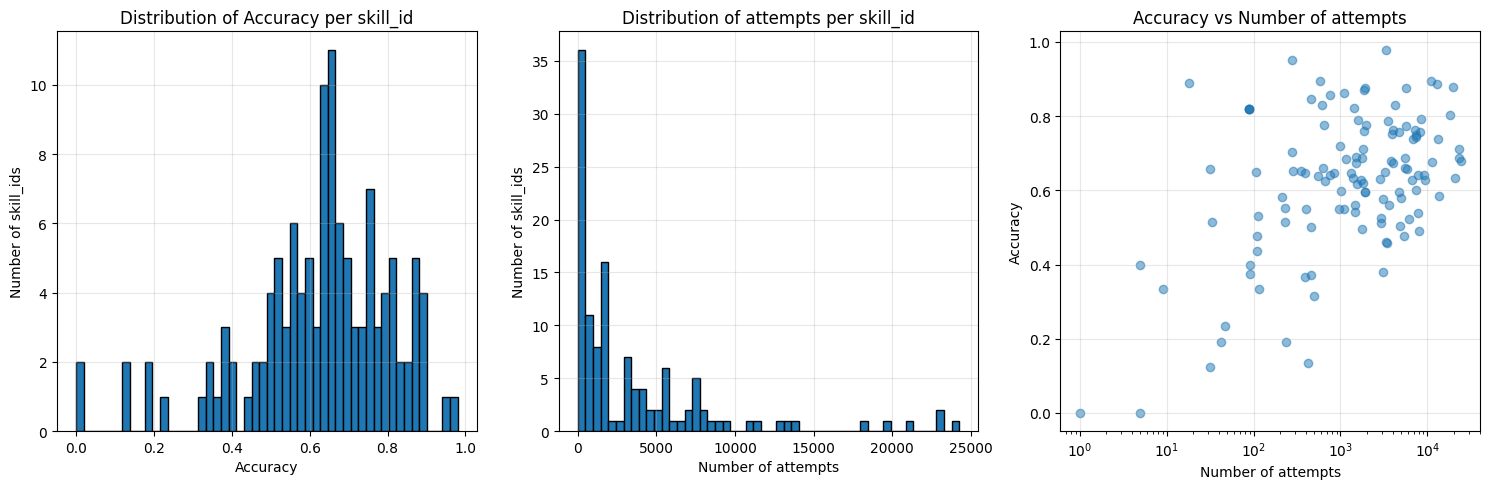


【サマリー】
総skill_id数: 123
平均正解率: 0.6233
中央値正解率: 0.6465
正解率 >= 0.8 のskill_id: 21 (17.07%)
正解率 < 0.5 のskill_id: 23 (18.70%)


In [19]:
# skill_idごとの正解率を集計
print("=== skill_idごとの正解率集計 ===")

# correctカラムが存在するか確認
if 'correct' in df.columns:
    df_clean = df[['skill_id', 'correct']].dropna()
    
    # 各skill_idの正解率を計算
    skill_accuracy = df_clean.groupby('skill_id').agg({
        'correct': ['mean', 'sum', 'count']
    }).reset_index()
    
    skill_accuracy.columns = ['skill_id', 'accuracy', 'n_correct', 'n_total']
    skill_accuracy = skill_accuracy.sort_values('accuracy', ascending=False)
    
    print("\n【基本統計】")
    print(skill_accuracy['accuracy'].describe())
    
    print("\n【正解率が高いskill_idのTOP 20】")
    display(skill_accuracy.head(20))
    
    print("\n【正解率が低いskill_idのTOP 20】")
    display(skill_accuracy.tail(20))
    
    # ヒストグラム
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.hist(skill_accuracy['accuracy'], bins=50, edgecolor='black')
    plt.xlabel('Accuracy')
    plt.ylabel('Number of skill_ids')
    plt.title('Distribution of Accuracy per skill_id')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.hist(skill_accuracy['n_total'], bins=50, edgecolor='black')
    plt.xlabel('Number of attempts')
    plt.ylabel('Number of skill_ids')
    plt.title('Distribution of attempts per skill_id')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.scatter(skill_accuracy['n_total'], skill_accuracy['accuracy'], alpha=0.5)
    plt.xlabel('Number of attempts')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Number of attempts')
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n【サマリー】")
    print(f"総skill_id数: {len(skill_accuracy)}")
    print(f"平均正解率: {skill_accuracy['accuracy'].mean():.4f}")
    print(f"中央値正解率: {skill_accuracy['accuracy'].median():.4f}")
    print(f"正解率 >= 0.8 のskill_id: {(skill_accuracy['accuracy'] >= 0.8).sum()} ({(skill_accuracy['accuracy'] >= 0.8).sum() / len(skill_accuracy) * 100:.2f}%)")
    print(f"正解率 < 0.5 のskill_id: {(skill_accuracy['accuracy'] < 0.5).sum()} ({(skill_accuracy['accuracy'] < 0.5).sum() / len(skill_accuracy) * 100:.2f}%)")
    
else:
    print("'correct'カラムが見つかりません")
    print(f"利用可能なカラム: {df.columns.tolist()}")

=== template_idごとの平均スキル数 ===

【基本統計】
平均スキル数(problem_idレベル)の統計:
count    658.000000
mean       1.188997
std        0.471020
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.000000
Name: avg_skills_per_problem, dtype: float64

template_id全体のユニークスキル数の統計:
count    658.000000
mean       1.240122
std        0.551821
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.000000
Name: total_unique_skills, dtype: float64

【平均スキル数が多いtemplate_idのTOP 20】


,template_id,total_unique_skills,avg_skills_per_problem
411,52571,4,4.000000
471,56516,4,4.000000
646,89341,4,4.000000
1,252,4,3.608696
201,30790,4,3.277610
8,4015,4,3.250000
299,42053,3,3.000000
321,42863,3,3.000000
152,30397,3,3.000000
410,52570,3,3.000000



【平均スキル数が少ないtemplate_idのTOP 20】


,template_id,total_unique_skills,avg_skills_per_problem
273,32882,1,1.0
281,33267,1,1.0
257,31956,1,1.0
255,31692,2,1.0
254,31691,1,1.0
253,31690,1,1.0
252,31689,1,1.0
251,31688,2,1.0
250,31687,1,1.0
249,31684,1,1.0


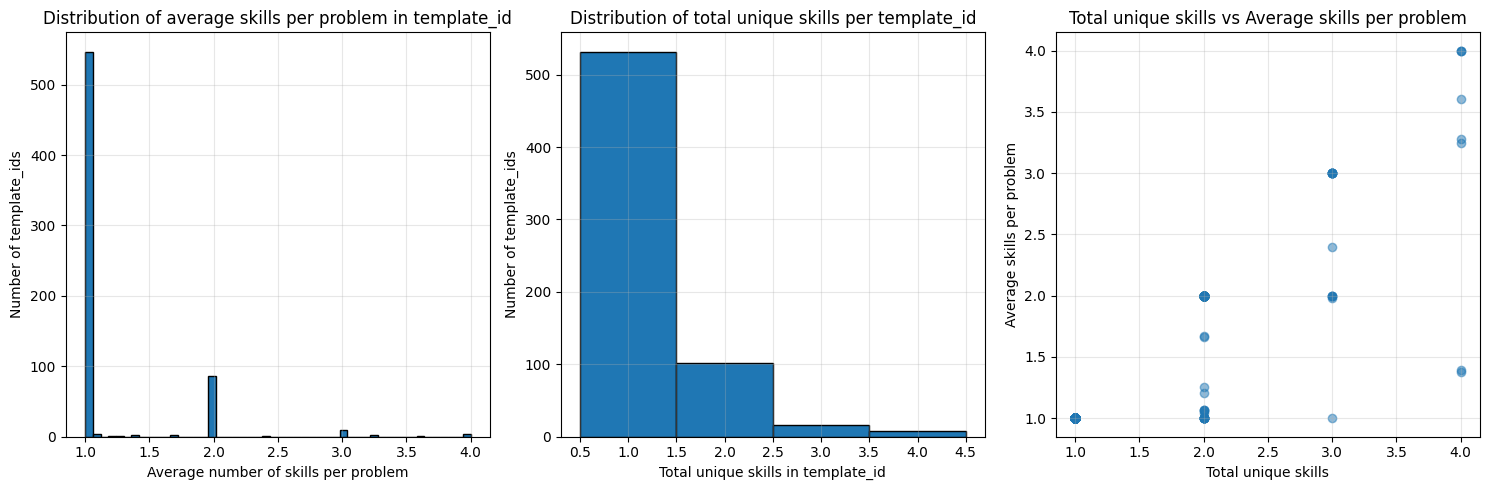


【サマリー】
総template_id数: 658
平均スキル数(problem_idレベル)の全体平均: 1.1890
平均スキル数(problem_idレベル)の中央値: 1.0000
template_id全体のユニークスキル数の平均: 1.24


In [20]:
# 各template_idについて、行ごとのスキル数の平均を計算
print("=== template_idごとの平均スキル数 ===")

# 必要なカラムを含むデータフレームを作成
df_clean = df[['template_id', 'problem_id', 'skill_id']].dropna()

# 方法1: template_id全体で見たときの平均スキル数
# (各template_idが持つユニークなskill_idの数)
template_total_skills = df_clean.groupby('template_id')['skill_id'].nunique().reset_index()
template_total_skills.columns = ['template_id', 'total_unique_skills']

# 方法2: 各レコードレベルでの平均
# 各template_idのレコード(行)について、そのレコードが関連するskill_idの数の平均
# (同じproblem_idの行は同じskill_id数を持つ)

# まず、各problem_idが持つskill_idの数を計算
problem_skill_count = df_clean.groupby('problem_id')['skill_id'].nunique().to_dict()

# template_idとproblem_idの対応を取得
df_with_counts = df_clean[['template_id', 'problem_id']].copy()
df_with_counts['n_skills_per_problem'] = df_with_counts['problem_id'].map(problem_skill_count)

# 各template_idについて、problem_idレベルでの平均スキル数を計算
template_avg_skills = df_with_counts.groupby('template_id')['n_skills_per_problem'].mean().reset_index()
template_avg_skills.columns = ['template_id', 'avg_skills_per_problem']

# 2つの指標を統合
template_skill_stats = template_total_skills.merge(template_avg_skills, on='template_id')
template_skill_stats = template_skill_stats.sort_values('avg_skills_per_problem', ascending=False)

print("\n【基本統計】")
print(f"平均スキル数(problem_idレベル)の統計:")
print(template_skill_stats['avg_skills_per_problem'].describe())
print(f"\ntemplate_id全体のユニークスキル数の統計:")
print(template_skill_stats['total_unique_skills'].describe())

print("\n【平均スキル数が多いtemplate_idのTOP 20】")
display(template_skill_stats.head(20))

print("\n【平均スキル数が少ないtemplate_idのTOP 20】")
display(template_skill_stats.tail(20))

# ヒストグラム
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(template_skill_stats['avg_skills_per_problem'], bins=50, edgecolor='black')
plt.xlabel('Average number of skills per problem')
plt.ylabel('Number of template_ids')
plt.title('Distribution of average skills per problem in template_id')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(template_skill_stats['total_unique_skills'], bins=range(1, int(template_skill_stats['total_unique_skills'].max())+2), 
         edgecolor='black', align='left')
plt.xlabel('Total unique skills in template_id')
plt.ylabel('Number of template_ids')
plt.title('Distribution of total unique skills per template_id')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(template_skill_stats['total_unique_skills'], 
           template_skill_stats['avg_skills_per_problem'], alpha=0.5)
plt.xlabel('Total unique skills')
plt.ylabel('Average skills per problem')
plt.title('Total unique skills vs Average skills per problem')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n【サマリー】")
print(f"総template_id数: {len(template_skill_stats)}")
print(f"平均スキル数(problem_idレベル)の全体平均: {template_skill_stats['avg_skills_per_problem'].mean():.4f}")
print(f"平均スキル数(problem_idレベル)の中央値: {template_skill_stats['avg_skills_per_problem'].median():.4f}")
print(f"template_id全体のユニークスキル数の平均: {template_skill_stats['total_unique_skills'].mean():.2f}")

=== template_id→skill_id対応の一意化による例外分析 ===

【全体統計】
総template_id数: 658

例外率(problem_idベース)の統計:
count    658.000000
mean       1.359605
std        7.596729
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       75.000000
Name: exception_rate_by_problem, dtype: float64

例外率(レコードベース)の統計:
count    658.000000
mean       1.412724
std        8.581922
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       95.652174
Name: exception_rate_by_record, dtype: float64

【一意化による影響が大きいtemplate_id TOP 20】

【全体統計】
総template_id数: 658

例外率(problem_idベース)の統計:
count    658.000000
mean       1.359605
std        7.596729
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       75.000000
Name: exception_rate_by_problem, dtype: float64

例外率(レコードベース)の統計:
count    658.000000
mean       1.412724
std        8.581922
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       95.652174
Nam

,template_id,total_problems,n_unique_skill_combos,most_common_skills,most_common_count,most_common_rate,exception_problems,exception_rate_by_problem,total_records,exception_records,exception_rate_by_record,total_unique_skills
239,252,4,4,[63.0],1,25.000000,3,75.000000,23,22,95.652174,4
238,86,4,4,[63.0],1,25.000000,3,75.000000,43,39,90.697674,3
234,4015,3,3,[63.0],1,33.333333,2,66.666667,16,14,87.500000,4
83,30419,30,2,[17.0],16,53.333333,14,46.666667,798,536,67.167920,2
90,30449,111,2,[16.0],81,72.972973,30,27.027027,1176,740,62.925170,2
606,60008,20,2,[378.0],10,50.000000,10,50.000000,99,59,59.595960,2
607,59998,20,2,[350.0],10,50.000000,10,50.000000,170,91,53.529412,2
55,30063,119,2,"[10.0, 18.0]",69,57.983193,50,42.016807,2351,797,33.900468,2
504,29981,60,2,[309.0],30,50.000000,30,50.000000,1246,418,33.547352,2
398,30861,20,5,[325.0],16,80.000000,4,20.000000,1142,380,33.274956,4



【一意化が完全に機能するtemplate_id(例外率0%)】
該当数: 624 / 658 (94.83%)

【複数のスキル組み合わせを持つtemplate_idの分析】
複数組み合わせを持つtemplate_id: 34 / 658 (5.17%)
これらの平均例外率(problem_idベース): 26.31%
これらの平均例外率(レコードベース): 27.34%

【重み付き例外率(全データ中の例外レコード割合)】
総レコード数: 459,208
例外レコード数: 10,737
例外率: 2.34%
→ Q行列を一意化すると、全データの2.34%が誤った対応付けとなる


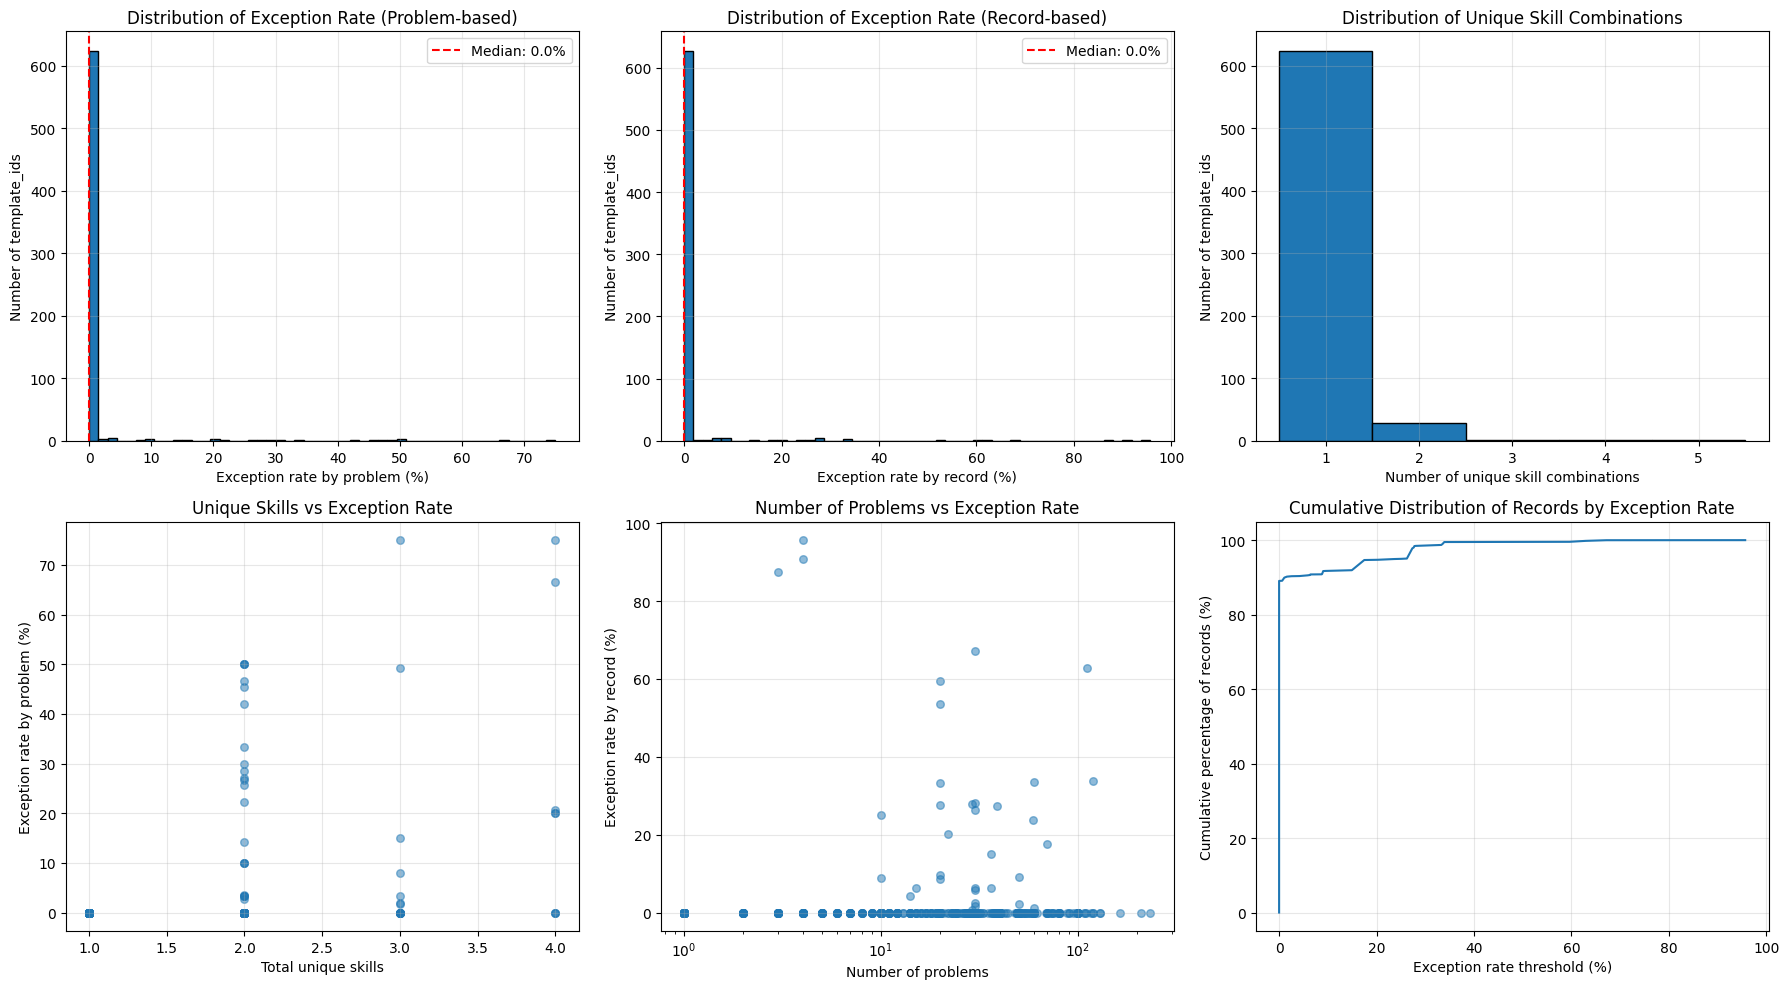


【例外率によるtemplate_idの分類】
1. 例外なし (0%): 624 個 (94.8%)
   レコード数: 408,943 (89.1%)
2. 低例外率 (0-10%): 14 個 (2.1%)
   レコード数: 12,311 (2.7%)
3. 中例外率 (10-30%): 10 個 (1.5%)
   レコード数: 30,890 (6.7%)
4. 高例外率 (>30%): 10 個 (1.5%)
   レコード数: 7,064 (1.5%)

【結論】
template_idとskill_idを一意に対応づけた場合:
- 624 個 (94.8%)のtemplate_idは完全に一意対応可能
- 全レコードの 2.34% が例外となり、誤った対応付けとなる
- 例外率の中央値: 0.00%


In [21]:
# template_idとskill_idを一意に対応づけた際の例外の定量化
print("=== template_id→skill_id対応の一意化による例外分析 ===")

df_clean = df[['template_id', 'problem_id', 'skill_id', 'correct']].dropna()

# 1. 各template_idについて、最も頻出するskill_idの組み合わせを「代表スキルセット」とする
template_skill_analysis = []

for template_id in df_clean['template_id'].unique():
    template_data = df_clean[df_clean['template_id'] == template_id]
    
    # このtemplate_idの全てのproblem_idとそのskill_id組み合わせ
    problem_skills = template_data.groupby('problem_id')['skill_id'].apply(lambda x: frozenset(x)).to_dict()
    
    # 最も頻出するskill_idの組み合わせを特定
    skill_combo_counts = {}
    for pid, skills in problem_skills.items():
        skill_combo_counts[skills] = skill_combo_counts.get(skills, 0) + 1
    
    # 最頻出の組み合わせ
    most_common_combo = max(skill_combo_counts.items(), key=lambda x: x[1])
    most_common_skills = most_common_combo[0]
    most_common_count = most_common_combo[1]
    
    # 全problem_id数
    total_problems = len(problem_skills)
    
    # 例外となるproblem_id数（最頻出と異なる組み合わせを持つもの）
    exception_problems = total_problems - most_common_count
    exception_rate = exception_problems / total_problems * 100 if total_problems > 0 else 0
    
    # レコード数ベースでの例外率
    total_records = len(template_data)
    exception_records = len(template_data[~template_data['problem_id'].isin(
        [pid for pid, skills in problem_skills.items() if skills == most_common_skills]
    )])
    exception_record_rate = exception_records / total_records * 100 if total_records > 0 else 0
    
    template_skill_analysis.append({
        'template_id': template_id,
        'total_problems': total_problems,
        'n_unique_skill_combos': len(skill_combo_counts),
        'most_common_skills': sorted(most_common_skills),
        'most_common_count': most_common_count,
        'most_common_rate': most_common_count / total_problems * 100,
        'exception_problems': exception_problems,
        'exception_rate_by_problem': exception_rate,
        'total_records': total_records,
        'exception_records': exception_records,
        'exception_rate_by_record': exception_record_rate,
        'total_unique_skills': template_data['skill_id'].nunique()
    })

result_df = pd.DataFrame(template_skill_analysis)
result_df = result_df.sort_values('exception_rate_by_record', ascending=False)

print("\n【全体統計】")
print(f"総template_id数: {len(result_df)}")
print(f"\n例外率(problem_idベース)の統計:")
print(result_df['exception_rate_by_problem'].describe())
print(f"\n例外率(レコードベース)の統計:")
print(result_df['exception_rate_by_record'].describe())

print("\n【一意化による影響が大きいtemplate_id TOP 20】")
display(result_df.head(20))

print("\n【一意化が完全に機能するtemplate_id(例外率0%)】")
perfect_templates = result_df[result_df['exception_rate_by_problem'] == 0]
print(f"該当数: {len(perfect_templates)} / {len(result_df)} ({len(perfect_templates)/len(result_df)*100:.2f}%)")

print("\n【複数のスキル組み合わせを持つtemplate_idの分析】")
multi_combo = result_df[result_df['n_unique_skill_combos'] > 1]
print(f"複数組み合わせを持つtemplate_id: {len(multi_combo)} / {len(result_df)} ({len(multi_combo)/len(result_df)*100:.2f}%)")
print(f"これらの平均例外率(problem_idベース): {multi_combo['exception_rate_by_problem'].mean():.2f}%")
print(f"これらの平均例外率(レコードベース): {multi_combo['exception_rate_by_record'].mean():.2f}%")

# 2. レコード数による重み付き例外率（実際の学習データへの影響）
total_records = result_df['total_records'].sum()
total_exception_records = result_df['exception_records'].sum()
weighted_exception_rate = total_exception_records / total_records * 100

print(f"\n【重み付き例外率(全データ中の例外レコード割合)】")
print(f"総レコード数: {total_records:,}")
print(f"例外レコード数: {total_exception_records:,}")
print(f"例外率: {weighted_exception_rate:.2f}%")
print(f"→ Q行列を一意化すると、全データの{weighted_exception_rate:.2f}%が誤った対応付けとなる")

# 3. 可視化
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 例外率(problem_idベース)の分布
axes[0, 0].hist(result_df['exception_rate_by_problem'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Exception rate by problem (%)')
axes[0, 0].set_ylabel('Number of template_ids')
axes[0, 0].set_title('Distribution of Exception Rate (Problem-based)')
axes[0, 0].axvline(result_df['exception_rate_by_problem'].median(), color='red', 
                    linestyle='--', label=f'Median: {result_df["exception_rate_by_problem"].median():.1f}%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 例外率(レコードベース)の分布
axes[0, 1].hist(result_df['exception_rate_by_record'], bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Exception rate by record (%)')
axes[0, 1].set_ylabel('Number of template_ids')
axes[0, 1].set_title('Distribution of Exception Rate (Record-based)')
axes[0, 1].axvline(result_df['exception_rate_by_record'].median(), color='red', 
                    linestyle='--', label=f'Median: {result_df["exception_rate_by_record"].median():.1f}%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ユニークスキル組み合わせ数の分布
axes[0, 2].hist(result_df['n_unique_skill_combos'], bins=range(1, result_df['n_unique_skill_combos'].max()+2),
                edgecolor='black', align='left')
axes[0, 2].set_xlabel('Number of unique skill combinations')
axes[0, 2].set_ylabel('Number of template_ids')
axes[0, 2].set_title('Distribution of Unique Skill Combinations')
axes[0, 2].grid(True, alpha=0.3)

# 総ユニークスキル数 vs 例外率(problem_idベース)
axes[1, 0].scatter(result_df['total_unique_skills'], result_df['exception_rate_by_problem'], 
                   alpha=0.5, s=30)
axes[1, 0].set_xlabel('Total unique skills')
axes[1, 0].set_ylabel('Exception rate by problem (%)')
axes[1, 0].set_title('Unique Skills vs Exception Rate')
axes[1, 0].grid(True, alpha=0.3)

# 問題数 vs 例外率(レコードベース)
axes[1, 1].scatter(result_df['total_problems'], result_df['exception_rate_by_record'], 
                   alpha=0.5, s=30)
axes[1, 1].set_xlabel('Number of problems')
axes[1, 1].set_ylabel('Exception rate by record (%)')
axes[1, 1].set_title('Number of Problems vs Exception Rate')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

# 累積分布(レコード数加重)
sorted_templates = result_df.sort_values('exception_rate_by_record')
sorted_templates['cumulative_records'] = sorted_templates['total_records'].cumsum()
sorted_templates['cumulative_pct'] = sorted_templates['cumulative_records'] / total_records * 100
axes[1, 2].plot(sorted_templates['exception_rate_by_record'], sorted_templates['cumulative_pct'])
axes[1, 2].set_xlabel('Exception rate threshold (%)')
axes[1, 2].set_ylabel('Cumulative percentage of records (%)')
axes[1, 2].set_title('Cumulative Distribution of Records by Exception Rate')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 例外率による分類
print("\n【例外率によるtemplate_idの分類】")
perfect = result_df[result_df['exception_rate_by_record'] == 0]
low = result_df[(result_df['exception_rate_by_record'] > 0) & (result_df['exception_rate_by_record'] <= 10)]
medium = result_df[(result_df['exception_rate_by_record'] > 10) & (result_df['exception_rate_by_record'] <= 30)]
high = result_df[result_df['exception_rate_by_record'] > 30]

print(f"1. 例外なし (0%): {len(perfect)} 個 ({len(perfect)/len(result_df)*100:.1f}%)")
print(f"   レコード数: {perfect['total_records'].sum():,} ({perfect['total_records'].sum()/total_records*100:.1f}%)")
print(f"2. 低例外率 (0-10%): {len(low)} 個 ({len(low)/len(result_df)*100:.1f}%)")
print(f"   レコード数: {low['total_records'].sum():,} ({low['total_records'].sum()/total_records*100:.1f}%)")
print(f"3. 中例外率 (10-30%): {len(medium)} 個 ({len(medium)/len(result_df)*100:.1f}%)")
print(f"   レコード数: {medium['total_records'].sum():,} ({medium['total_records'].sum()/total_records*100:.1f}%)")
print(f"4. 高例外率 (>30%): {len(high)} 個 ({len(high)/len(result_df)*100:.1f}%)")
print(f"   レコード数: {high['total_records'].sum():,} ({high['total_records'].sum()/total_records*100:.1f}%)")

print("\n【結論】")
print(f"template_idとskill_idを一意に対応づけた場合:")
print(f"- {len(perfect_templates)} 個 ({len(perfect_templates)/len(result_df)*100:.1f}%)のtemplate_idは完全に一意対応可能")
print(f"- 全レコードの {weighted_exception_rate:.2f}% が例外となり、誤った対応付けとなる")
print(f"- 例外率の中央値: {result_df['exception_rate_by_record'].median():.2f}%")